In [20]:
import numpy as np
from lgdo import lh5
from pathlib import Path
from matplotlib import pyplot as plt
import tol_colors as tc
import hist
import awkward as ak
from scipy.stats import beta, poisson, norm
import dbetto
import copy

plt.rcParams["lines.linewidth"] = 1
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.size"] = 14
vib = tc.tol_cset("vibrant")
vset = tc.tol_cset("vibrant")
mset = tc.tol_cset("muted")

style = {
    "yerr": False,
    "flow": None,
    "fill": False,
    "lw": 1,
}

# Get the BuPu colormap
cmap = plt.get_cmap("cividis")

In [26]:
def get_lh5(generator, name, val,threads = 8):
    path = f"{generator}/{name}/max_{val}/"
    hit_directory = Path(f"out/{path}/hit/")
    data = None
    
    for t in range(threads):
        dt = lh5.read_as("germanium/hit", f"{hit_directory}/out_t{t}.lh5", "ak")
        data = ak.concatenate((data,dt)) if data is not None else dt
    return data

n_sim = 10000000


In [3]:
def get_binomial_interval(npass, n):
    eff = npass / n
    quantiles = beta.ppf([0.16, 0.84], npass + 1, n - npass + 1)
    err_low = eff - quantiles[0]
    err_high = quantiles[1] - eff
    if err_high <= 0:
        quantiles = beta.ppf([1 - 0.68, 1], npass + 1, n - npass + 1)
        err_low = eff - quantiles[0]
        err_high = quantiles[1] - eff
    elif err_low <= 0:
        quantiles = beta.ppf([0, 0.68], npass + 1, n - npass + 1)
        err_low = eff - quantiles[0]
        err_high = quantiles[1] - eff
    return err_low, err_high

In [17]:
def normalized_poisson_residual(mu1,mu2)->np.ndarray:

    if (mu1==0 or mu2==0):
        return 0
        
    if (mu1>10 and mu2>10):
        return (mu1-mu2)/np.sqrt(mu1+mu2)
        
    samples = poisson.rvs(mu=float(mu1),size=100_000)- poisson.rvs(mu=float(mu2),size=100_000)
    counts = sum(samples>0)

    if (counts<5e4):
        sign = -1
        prob = counts/1e5
    else:
        sign = 1
        counts = 1e5-counts
        prob = (counts)/1e5
    if (prob==0):
        prob = 1e-5
    return sign * norm.ppf(1 - prob)

In [27]:
def plot(
    generator,
    xrange,
    cuts =[ 5, 10, 20, 50, 100, 200, 500,1000] ,
    names=["step_limits"],
    fields=["active_energy_pre"],
    de=2,
    scale="log",
    eff_title=None,
    ylims=None,
    eff_low=999,
    eff_high=1001,
    doeff=False,
    figsize=(12, 4),
    legend=True,
    binning=1,
    bs=100,
    factor=1,
    types="all",
    label="Energy [keV]",
):
    if binning is None:
        bins_tmp = np.linspace(xrange[0], xrange[1], bs)
    else:
        bins_tmp = bins

    if not isinstance(names, list):
        names = list(names)

    quants = {val / 10: [] for val in range(5)}
    effs = {}
    steps = {}
    eff_def = {}
    
    colors=[vib.orange,vib.blue,vib.magenta,vib.teal,vib.grey,vib. cyan]
    
    # get default
    for field in fields:
        effs[field]={}
        steps[field]={}

        fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios': [4, 1], "hspace": 0}, figsize=figsize,sharex=True)
        
        ak_obj = get_lh5(generator, f"def_lar_off_{types}", 0)
        ak_obj = ak_obj[ak_obj[field] != 0]
        ak_obj[field] = ak_obj[field] * factor
    
        hist_def = hist.Hist(hist.axis.Variable(bins_tmp)).fill(
            ak_obj[field].to_numpy() + 1e-4
        )
        
        c, bc = hist_def.to_numpy() 
        bc = bc[:-1]
        def_counts = copy.deepcopy(c)
        for b in range(hist_def.size - 2):
            hist_def[b] *= 1 / np.diff(bins_tmp)[b]
        
        
        eff_def[field] = ak.sum((ak_obj[field] > eff_low) & (ak_obj[field] < eff_high))
        ax = axs[0]
        
        for name_simple in names:

            name=f"{name_simple}_{types}"
            hist_def.plot(ax=axs[0],yerr=False, flow=None, fill=True, alpha=0.2,color=vib.blue, label="No limits")
    
            effs[field][name] = []
            steps[field][name] = []
    
            for idx, val in enumerate(cuts):

                
                ak_obj = get_lh5(generator, name, val)
                ak_obj = ak_obj[ak_obj[field] != 0]
                ak_obj[field] = ak_obj[field] * factor
    
                hist_tmp = hist.Hist(hist.axis.Variable(bins_tmp)).fill(
                    ak_obj[field].to_numpy() + 1e-4
                )

                if (idx==0):
                    c,_ = hist_tmp.to_numpy()
                    low_counts = copy.deepcopy(c)
                    
                for b in range(hist_tmp.size - 2):
                    hist_tmp[b] *= 1 / np.diff(bins_tmp)[b]
                
                if (idx==0 or idx==len(cuts)-1):
                    hist_tmp.plot(ax=axs[0],**style, label=f"{val} um ")
        
                    if legend:
                        axs[0].legend(loc="best")
                        axs[0].legend(ncol=2)
                        axs[0].get_legend().set_title(name)
                        
                    axs[0].set_yscale(scale)
                    axs[0].set_xlabel(label)
                    axs[0].set_ylabel("counts")
                    axs[0].set_xlim(*xrange)
        
                    if ylims is not None:
                        axs[0].set_ylim(*ylims)
    
                steps[field][name].append(val)
                effs[field][name].append(
                    ak.sum((ak_obj[field] > eff_low) & (ak_obj[field] < eff_high))
                )
            plt.tight_layout()

        
        resid = np.array([normalized_poisson_residual(mu,obs) for mu,obs in zip(def_counts,low_counts)])
        axs[1].axhspan(-3,3,color="red",alpha=0.2)
        axs[1].axhspan(-2,2,color="gold",alpha=0.2)
        axs[1].axhspan(-1,1,color="green",alpha=0.2)

        axs[1].errorbar(bc,resid,fmt=".",color="black")
        axs[1].set_xlabel(label)
        axs[1].set_ylabel("Resid")
        axs[1].set_ylim(-max(max(abs(resid)),4.9)-0.1,+max(max(abs(resid)),4.9)+0.1)
        if not doeff:
            return
    
    ## plot the efficiency
    fig, ax = plt.subplots()
    for idx,field in enumerate(effs.keys()):

        eff_def_low = 100 * get_binomial_interval(eff_def[field], n_sim)[0]
        eff_def_high = 100 * get_binomial_interval(eff_def[field], n_sim)[1]
        line = ax.axhline(y=100 * eff_def[field] / n_sim,  linestyle="--",color=colors[idx])

        ax.axhspan(
            ymin=100 * eff_def[field]/ n_sim - eff_def_low,
            ymax=100 * eff_def[field] / n_sim + eff_def_high,
            alpha=0.2,
            color= colors[idx]
        )
        ax.axhline(y=100 * eff_def[field] / n_sim,  linestyle="--",color=colors[idx])
        
        for name in effs[field].keys():
            e = effs[field][name]
            s = steps[field][name]
            err_low = [get_binomial_interval(et, n_sim)[0] * 100 for et in e]
            err_high = [get_binomial_interval(et, n_sim)[1] * 100 for et in e]
    
            ax.errorbar(
                s,
                100 * np.array(e) / n_sim,
                yerr=[err_low, err_high],
                fmt=".",
                linestyle="--",
                label=f"varying {field}",
                color=colors[idx]
            )

    
    ax.set_xlabel(f"{name} [um]")
    ax.set_ylabel("Efficiency [%]")
    ax.set_xscale("log")
    ax.set_title(f"Fraction of events in {eff_low} - {eff_high} ({label})")

    ax.legend(fontsize=12,loc="best")
    plt.tight_layout()


In [18]:
def plot_performance(generator, name="step_limits", namep=""):
    prof = dbetto.utils.load_dict("profile.yaml")[generator][name]

    size = []
    vals = []
    times = []
    for key, val in sorted(prof.items()):
        size.append(float(val["size"]))
        times.append(float(val["time"]))
        vals.append(float(key))

    idx = np.argsort(vals)
    size = np.array(size)[idx]
    vals = np.array(vals)[idx]
    times = np.array(times)[idx]

    # Create figure and first axis
    fig, ax1 = plt.subplots()

    # Plot the first dataset (sine wave)
    ax1.plot(vals, times, "b-*")
    ax1.set_xlabel(f"{name} [um]")
    ax1.set_ylabel("time [s]", color="b")
    ax1.tick_params(axis="y", labelcolor="b")
    ax1.set_ylim(0, 1.2 * ax1.get_ylim()[1])

    # Create a second y-axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot the second dataset (cosine wave)
    ax2.plot(vals, size, "r--.")

    ax2.set_ylabel("Size [MB]", color="r")

    ax2.tick_params(axis="y", labelcolor="r")
    ax2.set_ylim(0, 1.2 * ax2.get_ylim()[1])
    ax2.set_xscale("log")
    # Show the plot
    fig.tight_layout()  # Adjust layout
    
    plt.savefig(namep)

### Beta in bulk

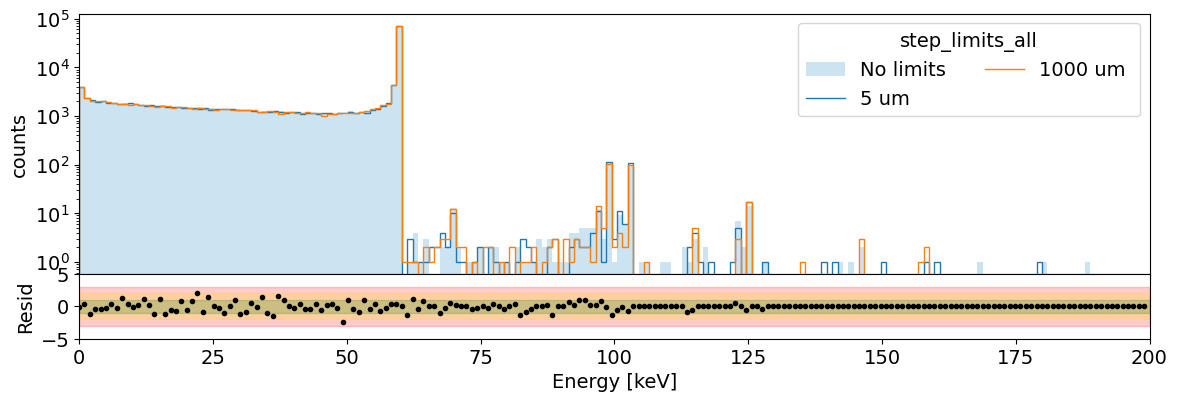

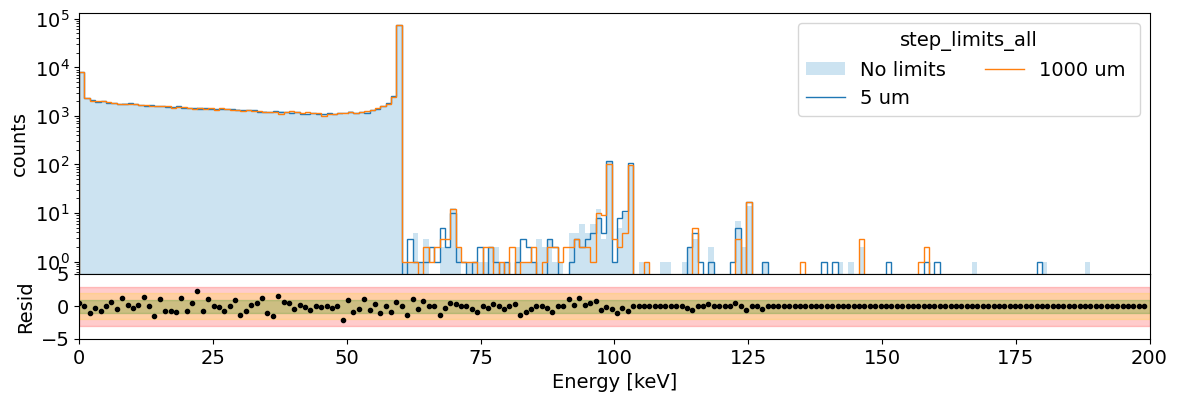

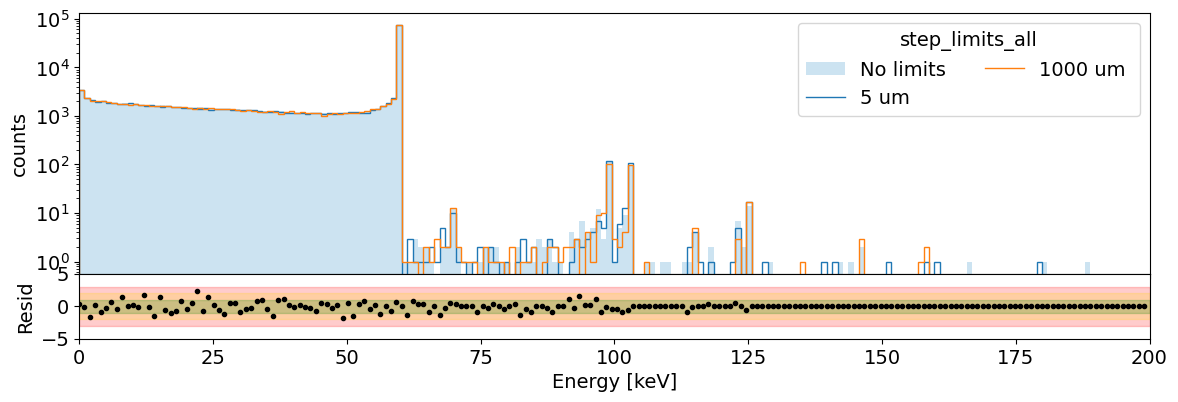

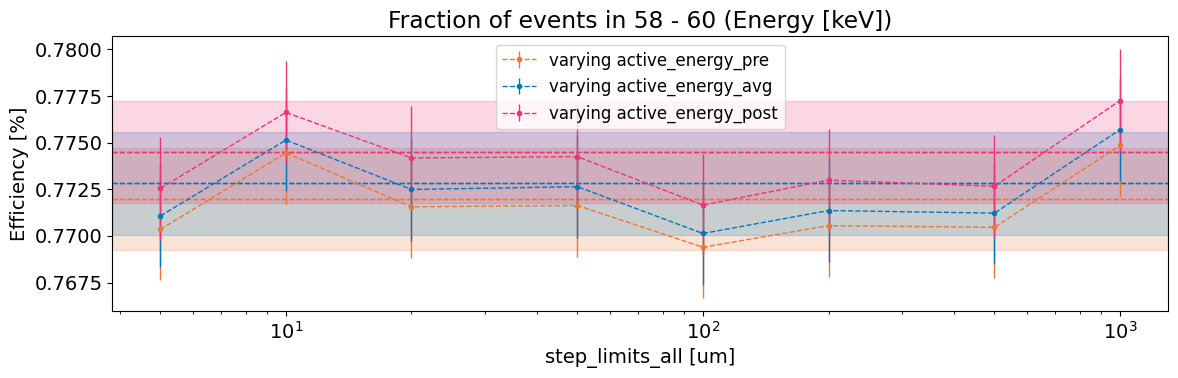

In [28]:
plot(
    "am241",
    (0,200),
    fields=["active_energy_pre","active_energy_avg","active_energy_post"],
    doeff=True,  
    eff_low = 58,
    eff_high = 60,
    binning = None,
    bs=200,
    figsize=(12, 4),
)

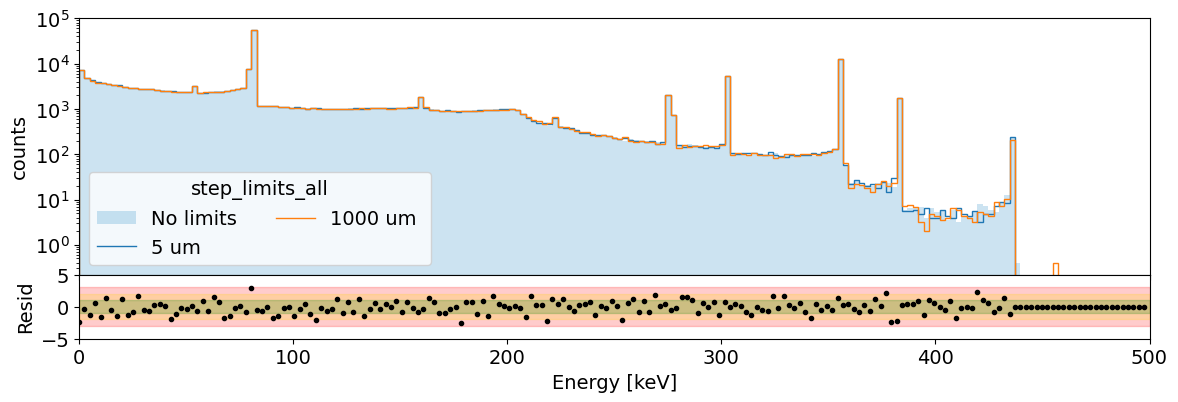

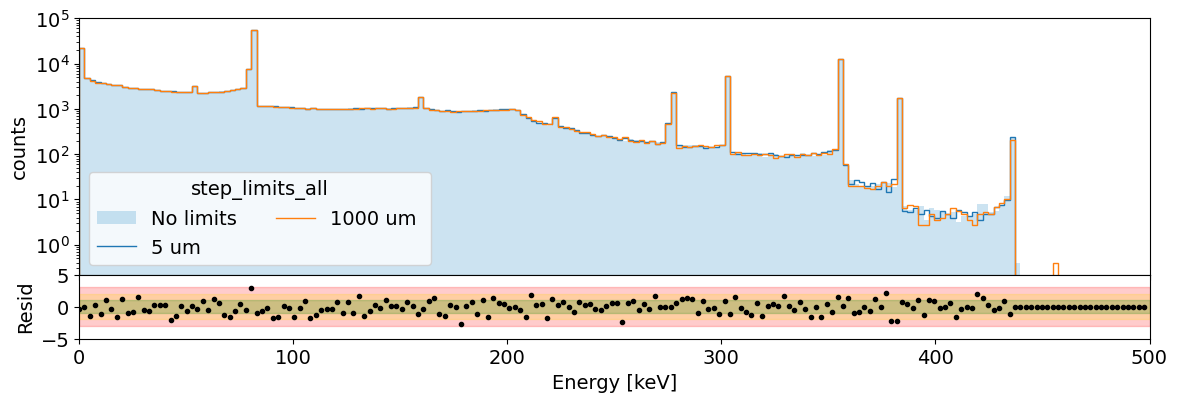

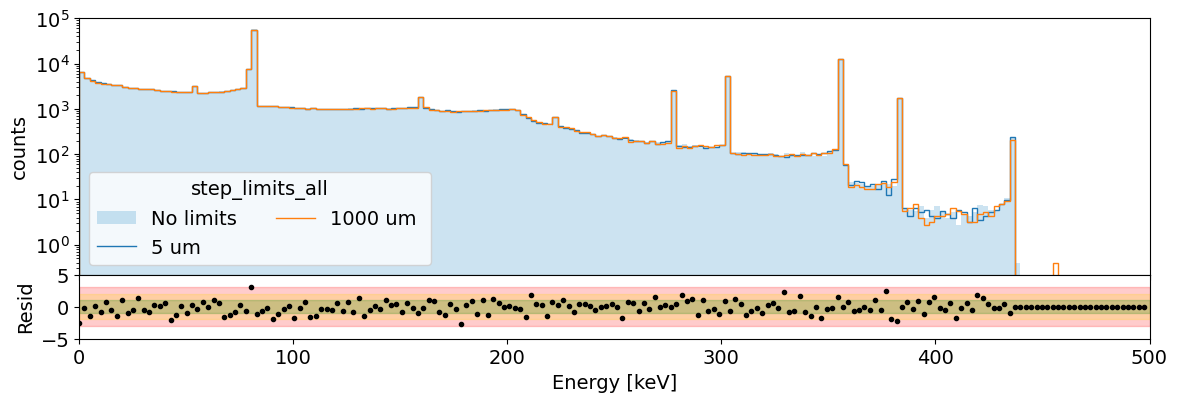

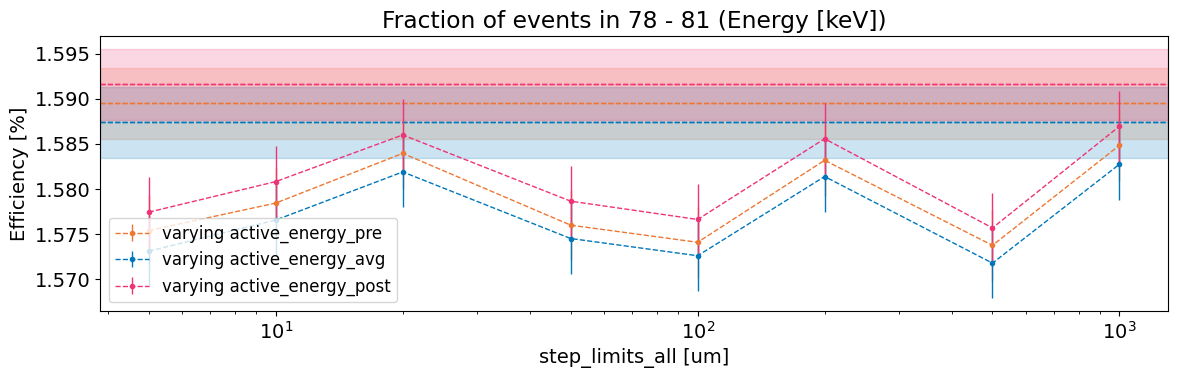

In [29]:
plot(
    "ba133",
    (0,500),
    fields=["active_energy_pre","active_energy_avg","active_energy_post"],
    doeff=True,  
    eff_low = 78,
    eff_high = 81,
    binning = None,
    bs=200,
    figsize=(12, 4),
)